# Crop Classification — Part 1
### Paper: *A Lightweight CNN-Transformer Network for Pixel-Based Crop Mapping Using Time-Series Sentinel-2 Imagery*

**Data source:** Google Earth Engine (same method as the paper)
**Study areas:** California & Arkansas, USA, 2021

## 0. Install dependencies

In [1]:
import subprocess, sys
pkgs = ["numpy","pandas","matplotlib","seaborn","scikit-learn","torch","torchvision","tqdm"]
subprocess.check_call([sys.executable,"-m","pip","install","-q"]+pkgs)
print("✅ All packages ready")

✅ All packages ready


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score, cohen_kappa_score)
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":120,"font.size":11})
print("✅ Imports OK")

✅ Imports OK


## 2. Configuration

In [7]:
# ── Paths to your CSV files ───────────────────────────────────────────
CALIFORNIA_CSV = r"C:\Users\HP\Desktop\SII\aarn\projet\MCTnet_california_2021_v2.csv"
ARKANSAS_CSV   = r"C:\Users\HP\Desktop\SII\aarn\projet\MCTnet_arkansas_2021_v2.csv"

# ── Paper settings ────────────────────────────────────────────────────
N_TIMESTEPS  = 36      # 10-day intervals across 2021
N_BANDS      = 10      # B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
N_SAMPLES    = 10000   # per study area
TRAIN_PER_CLASS = 240  # paper Table 2
VAL_PER_CLASS   = 60   # paper Table 2

# ── CDL crop codes ────────────────────────────────────────────────────
CDL_CLASSES_CA = {
    49: "Grapes", 3: "Rice", 36: "Alfalfa",
    75: "Almonds", 204: "Pistachios"
}
CDL_CLASSES_AR = {
    5: "Soybeans", 3: "Rice", 1: "Corn",
    2: "Cotton"
}

# ── Model hyperparameters (paper Table 3) ─────────────────────────────
HIDDEN_DIM  = 64
N_HEADS     = 5
N_STAGES    = 3
KERNEL_SIZE = 3
DROPOUT     = 0.1
BATCH_SIZE  = 32     # paper uses 32
EPOCHS      = 200    # paper uses 200
LR          = 0.001  # paper uses 0.001

print("✅ Config set")
print(f"   California CSV: {CALIFORNIA_CSV}")
print(f"   Arkansas CSV:   {ARKANSAS_CSV}")

✅ Config set
   California CSV: C:\Users\HP\Desktop\SII\aarn\projet\MCTnet_california_2021_v2.csv
   Arkansas CSV:   C:\Users\HP\Desktop\SII\aarn\projet\MCTnet_arkansas_2021_v2.csv


## 3. Load datasets

In [17]:
def load_dataset(csv_path, label_col='cropland'):
    """Load GEE-exported CSV and split into features X and labels y."""
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns (first 5): {list(df.columns[:5])}")
    print(f"  Label column: '{label_col}'")
    print(f"  Unique crop codes: {sorted(df[label_col].dropna().unique())}")

    # Drop geometry/system columns if present
    drop_cols = [c for c in df.columns if c.startswith('.geo') or
                 c.startswith('system') or c == label_col]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols].fillna(0).values.astype(np.float32)
    y = df[label_col].fillna(0).values.astype(np.int32)

    print(f"  Features shape: {X.shape}")
    print(f"  Labels shape:   {y.shape}")
    return X, y, df

# Load both study areas
X_ca, y_ca, df_ca = load_dataset(CALIFORNIA_CSV)
#X_ar, y_ar, df_ar = load_dataset(ARKANSAS_CSV)

Loaded: C:\Users\HP\Desktop\SII\aarn\projet\MCTnet_california_2021_v2.csv
  Shape: (67, 363)
  Columns (first 5): ['system:index', '0_B11', '0_B12', '0_B2', '0_B3']
  Label column: 'cropland'
  Unique crop codes: [np.int64(2), np.int64(6), np.int64(21), np.int64(24), np.int64(28), np.int64(36), np.int64(54), np.int64(59), np.int64(61), np.int64(69), np.int64(75), np.int64(111), np.int64(131), np.int64(152), np.int64(176), np.int64(195), np.int64(204), np.int64(209), np.int64(211)]
  Features shape: (67, 360)
  Labels shape:   (67,)


## 4. Data Exploration
### 4.1 Class distribution

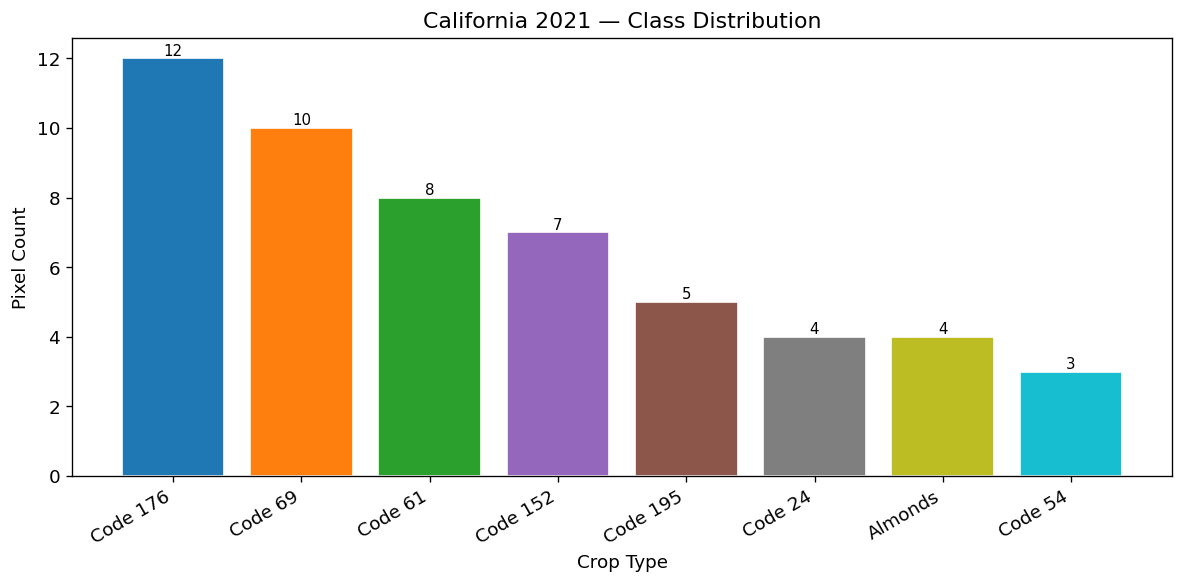

In [18]:
def plot_class_distribution(y, title, cdl_classes):
    from collections import Counter
    counts = Counter(y)
    # Map codes to names, group rare classes as 'Others'
    named = {}
    for code, cnt in counts.items():
        name = cdl_classes.get(int(code), f"Code {int(code)}")
        if name in named:
            named[name] += cnt
        else:
            named[name] = cnt

    # Sort by count
    named = dict(sorted(named.items(), key=lambda x: x[1], reverse=True))
    top = dict(list(named.items())[:8])  # top 8 classes

    fig, ax = plt.subplots(figsize=(10,5))
    colors = plt.cm.tab10(np.linspace(0,1,len(top)))
    bars = ax.bar(list(top.keys()), list(top.values()), color=colors,
                  edgecolor='white')
    ax.bar_label(bars, fmt='%d', fontsize=9)
    ax.set(title=title, xlabel='Crop Type', ylabel='Pixel Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f"class_dist_{title[:2].lower()}.png", dpi=150)
    plt.show()

# All CDL codes combined for lookup
all_cdl = {**CDL_CLASSES_CA, **CDL_CLASSES_AR}

plot_class_distribution(y_ca, "California 2021 — Class Distribution", all_cdl)
#plot_class_distribution(y_ar, "Arkansas 2021 — Class Distribution",   all_cdl)

### 4.2 NDVI time-series visualization

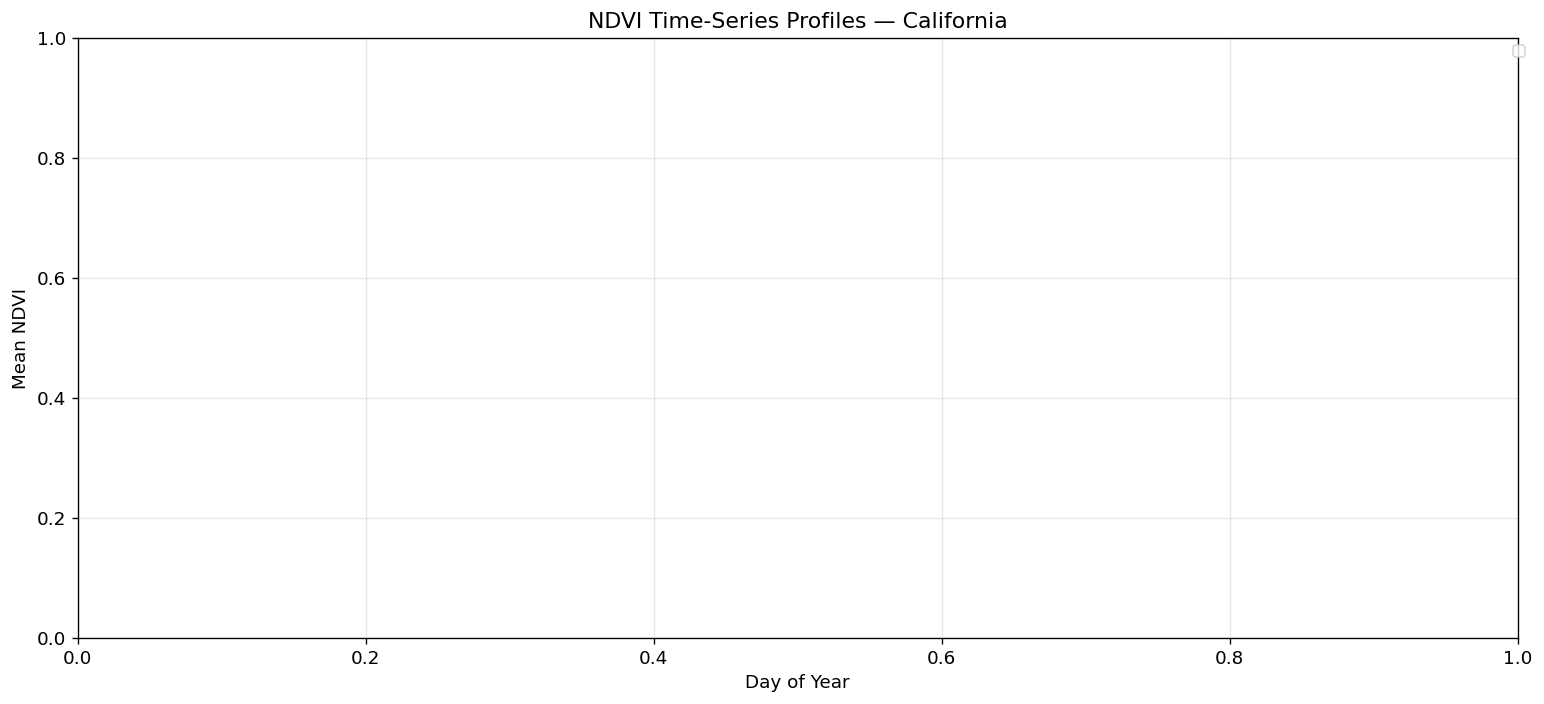

In [19]:
def compute_ndvi_from_features(X, n_timesteps=36, n_bands=10):
    """
    Feature columns from GEE are ordered: t0_B2, t0_B3 ... t0_B8A, t0_B11, t0_B12,
                                           t1_B2, ... t35_B12
    Band order: B2=0, B3=1, B4=2, B5=3, B6=4, B7=5, B8=6, B8A=7, B11=8, B12=9
    NDVI = (B8 - B4) / (B8 + B4) = (band6 - band2) / (band6 + band2)
    """
    ndvi = np.zeros((X.shape[0], n_timesteps))
    for t in range(n_timesteps):
        offset = t * n_bands
        b4  = X[:, offset + 2].astype(float)  # Red
        b8  = X[:, offset + 6].astype(float)  # NIR
        eps = 1e-8
        ndvi[:, t] = (b8 - b4) / (b8 + b4 + eps)
    return ndvi

def plot_ndvi_by_class(X, y, cdl_classes, title, n_timesteps=36):
    ndvi = compute_ndvi_from_features(X, n_timesteps)
    days = np.arange(5, 5 + n_timesteps*10, 10)  # DOY: 5,15,25...

    fig, ax = plt.subplots(figsize=(13,6))
    colors = plt.cm.tab10(np.linspace(0,1,len(cdl_classes)))

    for (code, name), color in zip(cdl_classes.items(), colors):
        mask = y == code
        if mask.sum() < 5:
            continue
        mean_ndvi = ndvi[mask].mean(axis=0)
        ax.plot(days, mean_ndvi, 'o-', label=name, color=color, lw=2, ms=4)

    ax.set(xlabel='Day of Year', ylabel='Mean NDVI',
           title=f'NDVI Time-Series Profiles — {title}')
    ax.legend(bbox_to_anchor=(1.01,1), fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ndvi_{title[:2].lower()}.png", dpi=150)
    plt.show()

plot_ndvi_by_class(X_ca, y_ca, CDL_CLASSES_CA, "California")
#plot_ndvi_by_class(X_ar, y_ar, CDL_CLASSES_AR, "Arkansas")

### 4.3 Missing values analysis

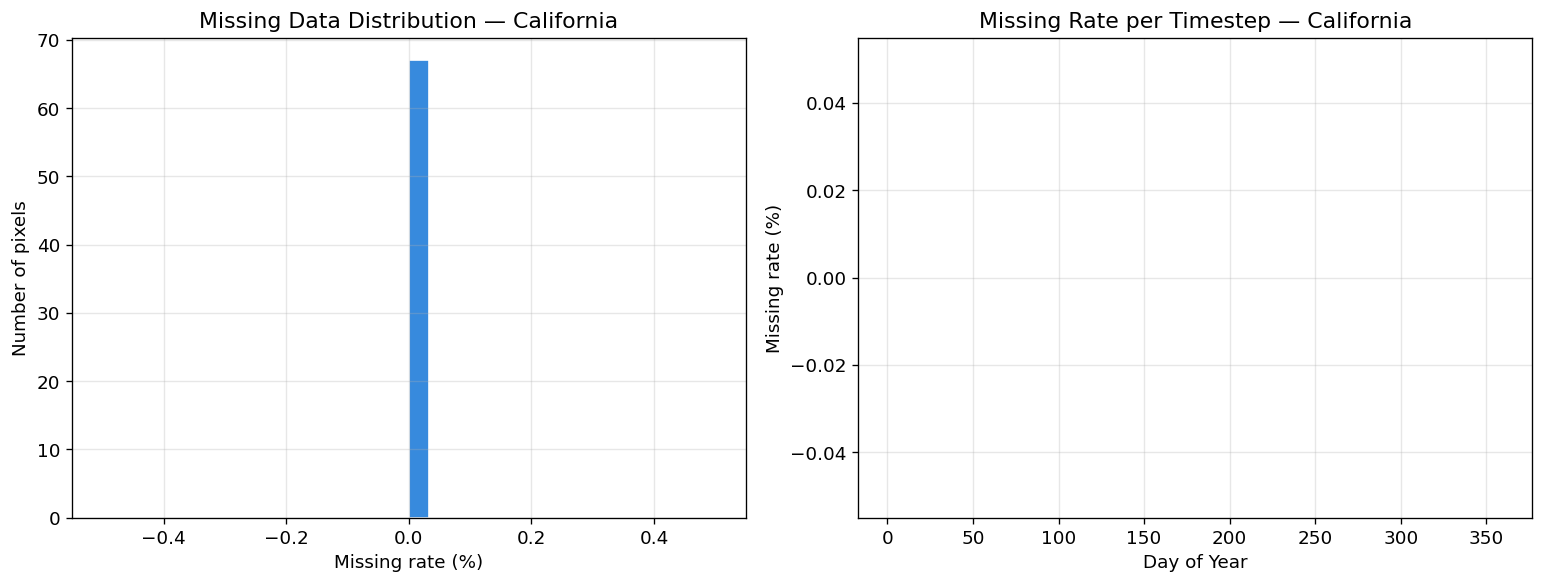

California — avg missing rate: 0.0%


NameError: name 'X_ar' is not defined

In [12]:
def plot_missing_values(X, title, n_timesteps=36, n_bands=10):
    """Count timesteps with all-zero bands (= missing in the paper)."""
    missing_per_sample = np.zeros(X.shape[0])
    for t in range(n_timesteps):
        offset = t * n_bands
        band_slice = X[:, offset:offset+n_bands]
        is_missing = (band_slice == 0).all(axis=1)
        missing_per_sample += is_missing.astype(float)

    missing_rate = missing_per_sample / n_timesteps * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
    ax1.hist(missing_rate, bins=30, color='#378ADD', edgecolor='white')
    ax1.set(xlabel='Missing rate (%)', ylabel='Number of pixels',
            title=f'Missing Data Distribution — {title}')
    ax1.grid(alpha=0.3)

    # Per-timestep missing rate
    timestep_missing = []
    days = np.arange(5, 5+n_timesteps*10, 10)
    for t in range(n_timesteps):
        offset = t * n_bands
        band_slice = X[:, offset:offset+n_bands]
        rate = (band_slice == 0).all(axis=1).mean() * 100
        timestep_missing.append(rate)

    ax2.bar(days, timestep_missing, color='#E63946', width=8)
    ax2.set(xlabel='Day of Year', ylabel='Missing rate (%)',
            title=f'Missing Rate per Timestep — {title}')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"missing_{title[:2].lower()}.png", dpi=150)
    plt.show()
    print(f"{title} — avg missing rate: {missing_rate.mean():.1f}%")

plot_missing_values(X_ca, "California")
plot_missing_values(X_ar, "Arkansas")

## 5. Preprocessing
### 5.1 Normalize and prepare missing mask

In [13]:
def prepare_dataset(X, y, cdl_classes, train_per_class=240,
                    val_per_class=60, n_timesteps=36, n_bands=10):
    """
    Replicate paper's data preparation:
    - Keep only target crop classes
    - Build missing mask (Input 2 in the paper)
    - Normalize features
    - Split train/val/test (paper Table 2)
    """
    valid_codes = list(cdl_classes.keys())
    # Keep target classes + label rare ones as 'others' (code 0)
    mask = np.isin(y, valid_codes)
    X_filt = X[mask]
    y_filt = y[mask]

    # Build missing mask: 1 = valid, 0 = missing (paper §2.3)
    missing_mask = np.zeros((X_filt.shape[0], n_timesteps), dtype=np.float32)
    for t in range(n_timesteps):
        offset = t * n_bands
        band_slice = X_filt[:, offset:offset+n_bands]
        is_valid = ~(band_slice == 0).all(axis=1)
        missing_mask[:, t] = is_valid.astype(float)

    # Reshape to (N, T, C)
    X_3d = X_filt.reshape(X_filt.shape[0], n_timesteps, n_bands)

    # Normalize per channel (z-score)
    flat = X_3d.reshape(-1, n_bands)
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    X_norm = (X_3d - mean) / std

    # Encode labels
    le = LabelEncoder()
    le.fit(valid_codes)
    y_enc = le.transform(y_filt)

    # Split: train/val = train_per_class+val_per_class per class, rest = test
    np.random.seed(42)
    train_idx, val_idx, test_idx = [], [], []
    for cls in range(len(valid_codes)):
        cls_idx = np.where(y_enc == cls)[0]
        np.random.shuffle(cls_idx)
        n_tv = train_per_class + val_per_class
        if len(cls_idx) >= n_tv:
            train_idx.extend(cls_idx[:train_per_class])
            val_idx.extend(cls_idx[train_per_class:n_tv])
            test_idx.extend(cls_idx[n_tv:])
        else:
            # Not enough samples — use 70/15/15 split
            t1 = int(len(cls_idx)*0.7)
            t2 = int(len(cls_idx)*0.85)
            train_idx.extend(cls_idx[:t1])
            val_idx.extend(cls_idx[t1:t2])
            test_idx.extend(cls_idx[t2:])

    splits = {}
    for name, idx in [('train',train_idx),('val',val_idx),('test',test_idx)]:
        splits[name] = {
            'X': X_norm[idx],
            'mask': missing_mask[idx],
            'y': y_enc[idx]
        }

    print(f"  Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
    print(f"  Classes: {[cdl_classes[c] for c in valid_codes]}")
    return splits, le, mean, std, valid_codes

print("Preparing California dataset...")
splits_ca, le_ca, mean_ca, std_ca, codes_ca = prepare_dataset(
    X_ca, y_ca, CDL_CLASSES_CA, TRAIN_PER_CLASS, VAL_PER_CLASS)

print("\nPreparing Arkansas dataset...")
splits_ar, le_ar, mean_ar, std_ar, codes_ar = prepare_dataset(
    X_ar, y_ar, CDL_CLASSES_AR, TRAIN_PER_CLASS, VAL_PER_CLASS)

Preparing California dataset...
  Train: 4 | Val: 1 | Test: 3
  Classes: ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios']

Preparing Arkansas dataset...


NameError: name 'X_ar' is not defined

## 6. MCTNet Model Implementation
### 6.1 Architecture (Paper §2.3)

In [14]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✅ PyTorch {torch.__version__} | device: {device}")
except ImportError:
    TORCH_OK = False
    print("❌ Install PyTorch: pip install torch")

✅ PyTorch 2.10.0+cpu | device: cpu


In [15]:
if TORCH_OK:

    class ALPE(nn.Module):
        """
        Attention-based Learnable Positional Encoding (paper §2.3.1, Fig.5)
        Uses missing mask to reduce impact of missing timesteps.
        """
        def __init__(self, n_timesteps, d_model):
            super().__init__()
            # Absolute positional encoding (sinusoidal base)
            pe = torch.zeros(n_timesteps, d_model)
            pos = torch.arange(n_timesteps).unsqueeze(1).float()
            div = torch.exp(torch.arange(0, d_model, 2).float() *
                            -(np.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div)
            pe[:, 1::2] = torch.cos(pos * div)
            self.register_buffer('pe', pe)

            # Learnable part: 1D conv + ECA (paper Fig.5)
            self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
            self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x, mask):
            # x: (B, T, D), mask: (B, T)
            B, T, D = x.shape
            pe = self.pe.unsqueeze(0).expand(B, -1, -1)  # (B,T,D)
            # Apply mask — zero out missing positions (paper eq.3)
            mask_exp = mask.unsqueeze(-1).expand_as(pe)
            masked_pe = pe * mask_exp
            # 1D conv along time
            out = self.conv(masked_pe.permute(0,2,1)).permute(0,2,1)
            # ECA: efficient channel attention
            gap = out.mean(dim=2, keepdim=True).permute(0,2,1)
            attn = self.sigmoid(self.eca_conv(gap)).permute(0,2,1)
            return out * attn


    class CNNSubModule(nn.Module):
        """1D CNN sub-module with residual connection (paper §2.3.2, Fig.6)"""
        def __init__(self, d_model, kernel_size=3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(d_model),
                nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(d_model),
            )
            self.relu = nn.ReLU()

        def forward(self, x):
            # x: (B, T, D) → conv expects (B, D, T)
            residual = x
            out = self.net(x.permute(0,2,1)).permute(0,2,1)
            return self.relu(out + residual)


    class TransformerSubModule(nn.Module):
        """Transformer encoder sub-module (paper §2.3.1, Fig.4)"""
        def __init__(self, d_model, n_heads, dropout=0.1):
            super().__init__()
            self.attn = nn.MultiheadAttention(d_model, n_heads,
                                               dropout=dropout,
                                               batch_first=True)
            self.ff = nn.Sequential(
                nn.Linear(d_model, d_model*4),
                nn.GELU(),
                nn.Linear(d_model*4, d_model)
            )
            self.norm1 = nn.LayerNorm(d_model)
            self.norm2 = nn.LayerNorm(d_model)
            self.drop  = nn.Dropout(dropout)

        def forward(self, x):
            # Multi-head self-attention + residual
            attn_out, _ = self.attn(x, x, x)
            x = self.norm1(x + self.drop(attn_out))
            # Feed-forward + residual
            x = self.norm2(x + self.drop(self.ff(x)))
            return x


    class CTFusionModule(nn.Module):
        """CNN-Transformer Fusion module — one stage (paper Fig.3)"""
        def __init__(self, d_model, n_heads, kernel_size=3, dropout=0.1):
            super().__init__()
            self.cnn = CNNSubModule(d_model, kernel_size)
            self.transformer = TransformerSubModule(d_model, n_heads, dropout)
            self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)

        def forward(self, x, pos_enc=None):
            # x: (B, T, D)
            cnn_out = self.cnn(x)
            if pos_enc is not None:
                x_trans = x + pos_enc
            else:
                x_trans = x
            trans_out = self.transformer(x_trans)
            # Concatenate CNN and Transformer outputs (paper Fig.3)
            fused = torch.cat([cnn_out, trans_out], dim=-1)
            # Max pooling along time (paper Fig.3)
            fused = self.pool(fused.permute(0,2,1)).permute(0,2,1)
            return fused


    class MCTNet(nn.Module):
        """
        Multi-stage CNN-Transformer Network (paper §2.3, Fig.3)
        Input 1: (B, T, C) — spectral time series
        Input 2: (B, T)    — missing mask
        Output:  (B, n_classes)
        """
        def __init__(self, n_bands, n_timesteps, n_classes,
                     d_model=64, n_heads=5, n_stages=3,
                     kernel_size=3, dropout=0.1):
            super().__init__()
            self.input_proj = nn.Linear(n_bands, d_model)
            self.alpe = ALPE(n_timesteps, d_model)

            # 3 CTFusion stages — each doubles d_model via concat
            self.stages = nn.ModuleList()
            in_dim = d_model
            for i in range(n_stages):
                self.stages.append(
                    CTFusionModule(in_dim, n_heads, kernel_size, dropout))
                in_dim = in_dim * 2  # concat doubles dim

            # Global max pooling + MLP classifier (paper §2.3.2)
            self.classifier = nn.Sequential(
                nn.Linear(in_dim, n_classes)
            )

        def forward(self, x, mask):
            # Project input to d_model
            x = self.input_proj(x)          # (B, T, D)
            # ALPE: learnable positional encoding with missing mask
            pos_enc = self.alpe(x, mask)    # (B, T, D)
            # Pass through stages
            for i, stage in enumerate(self.stages):
                pe = pos_enc if i == 0 else None
                x = stage(x, pe)
                # Update pos_enc size after pooling
                if i == 0 and pos_enc is not None:
                    pos_enc = pos_enc[:, ::2, :]  # downsample
            # Global max pooling along time
            x = x.max(dim=1)[0]             # (B, D)
            return self.classifier(x)        # (B, n_classes)

    print("✅ MCTNet architecture defined")
    print(f"   Stages: {N_STAGES} | Heads: {N_HEADS} | Hidden: {HIDDEN_DIM}")

✅ MCTNet architecture defined
   Stages: 3 | Heads: 5 | Hidden: 64


## 7. Training

In [16]:
if TORCH_OK:

    def make_loaders(splits, batch_size=32):
        loaders = {}
        for split, data in splits.items():
            X_t = torch.tensor(data['X'],    dtype=torch.float32)
            m_t = torch.tensor(data['mask'], dtype=torch.float32)
            y_t = torch.tensor(data['y'],    dtype=torch.long)
            ds  = TensorDataset(X_t, m_t, y_t)
            loaders[split] = DataLoader(
                ds, batch_size=batch_size,
                shuffle=(split=='train'))
        return loaders

    def train_one_area(splits, n_classes, area_name):
        loaders = make_loaders(splits, BATCH_SIZE)

        model = MCTNet(
            n_bands=N_BANDS, n_timesteps=N_TIMESTEPS,
            n_classes=n_classes, d_model=HIDDEN_DIM,
            n_heads=N_HEADS, n_stages=N_STAGES,
            kernel_size=KERNEL_SIZE, dropout=DROPOUT
        ).to(device)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"\n{area_name} — MCTNet parameters: {n_params:,}")

        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        criterion = nn.CrossEntropyLoss()

        history = {"train_loss":[],"val_loss":[],"val_f1":[]}
        best_val_f1 = 0

        for epoch in range(1, EPOCHS+1):
            # Train
            model.train()
            t_losses = []
            for xb, mb, yb in loaders['train']:
                xb,mb,yb = xb.to(device),mb.to(device),yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb,mb), yb)
                loss.backward(); optimizer.step()
                t_losses.append(loss.item())

            # Validate
            model.eval()
            v_losses, preds, trues = [], [], []
            with torch.no_grad():
                for xb,mb,yb in loaders['val']:
                    xb,mb,yb = xb.to(device),mb.to(device),yb.to(device)
                    out = model(xb,mb)
                    v_losses.append(criterion(out,yb).item())
                    preds.extend(out.argmax(1).cpu().numpy())
                    trues.extend(yb.cpu().numpy())

            scheduler.step()
            tl = np.mean(t_losses); vl = np.mean(v_losses)
            vf = f1_score(trues, preds, average='macro', zero_division=0)
            history['train_loss'].append(tl)
            history['val_loss'].append(vl)
            history['val_f1'].append(vf)

            if vf > best_val_f1:
                best_val_f1 = vf
                torch.save(model.state_dict(), f"mctnet_{area_name.lower()}_best.pt")

            if epoch % 20 == 0 or epoch == 1:
                print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                      f"train={tl:.4f} val={vl:.4f} F1={vf:.4f}")

        # Load best model for evaluation
        model.load_state_dict(
            torch.load(f"mctnet_{area_name.lower()}_best.pt",
                       map_location=device))
        return model, history, loaders

    # Train California
    model_ca, history_ca, loaders_ca = train_one_area(
        splits_ca, len(CDL_CLASSES_CA), "California")

    # Train Arkansas
    model_ar, history_ar, loaders_ar = train_one_area(
        splits_ar, len(CDL_CLASSES_AR), "Arkansas")

AssertionError: embed_dim must be divisible by num_heads

### 7.1 Learning curves

In [ ]:
if TORCH_OK:
    fig, axes = plt.subplots(2, 2, figsize=(14,8))
    for i, (history, name) in enumerate([(history_ca,"California"),
                                          (history_ar,"Arkansas")]):
        ax1, ax2 = axes[i]
        ax1.plot(history['train_loss'], label='Train', color='#E63946', lw=2)
        ax1.plot(history['val_loss'],   label='Val',   color='#457B9D', lw=2)
        ax1.set(title=f'{name} — Loss', xlabel='Epoch')
        ax1.legend(); ax1.grid(alpha=0.3)

        ax2.plot(history['val_f1'], color='#2A9D8F', lw=2)
        ax2.set(title=f'{name} — Val Macro F1', xlabel='Epoch')
        ax2.grid(alpha=0.3)

    plt.suptitle('Training History — MCTNet', fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

## 8. Evaluation on Test Set

In [ ]:
if TORCH_OK:

    def evaluate(model, loader, class_names, area_name):
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for xb, mb, yb in loader:
                xb, mb = xb.to(device), mb.to(device)
                all_preds.extend(model(xb,mb).argmax(1).cpu().numpy())
                all_true.extend(yb.numpy())

        oa    = accuracy_score(all_true, all_preds)
        kappa = cohen_kappa_score(all_true, all_preds)
        f1    = f1_score(all_true, all_preds, average='macro', zero_division=0)

        print(f"\n{'='*55}")
        print(f"  {area_name} — Test Results")
        print(f"{'='*55}")
        print(f"  Overall Accuracy (OA) : {oa:.4f}  (paper: 0.852)")
        print(f"  Kappa coefficient     : {kappa:.4f}  (paper: 0.806)")
        print(f"  Macro F1-Score        : {f1:.4f}  (paper: 0.829)")
        print(f"{'='*55}")
        print(classification_report(all_true, all_preds,
                                    target_names=class_names, zero_division=0))

        # Confusion matrix
        cm = confusion_matrix(all_true, all_preds)
        fig, ax = plt.subplots(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax,
                    linewidths=0.5)
        ax.set(xlabel='Predicted', ylabel='True',
               title=f'Confusion Matrix — {area_name}')
        plt.tight_layout()
        plt.savefig(f'confusion_{area_name.lower()}.png', dpi=150)
        plt.show()
        return oa, kappa, f1

    ca_names = list(CDL_CLASSES_CA.values())
    ar_names = list(CDL_CLASSES_AR.values())

    oa_ca, k_ca, f1_ca = evaluate(model_ca, loaders_ca['test'], ca_names, "California")
    oa_ar, k_ar, f1_ar = evaluate(model_ar, loaders_ar['test'], ar_names, "Arkansas")

## 9. Results Summary vs Paper

In [ ]:
if TORCH_OK:
    print("\n" + "="*60)
    print("  FINAL RESULTS vs PAPER (Table 5)")
    print("="*60)
    print(f"{'Area':<14} {'Metric':<10} {'Yours':<10} {'Paper':<10}")
    print("-"*44)
    print(f"{'California':<14} {'OA':<10} {oa_ca:<10.4f} {'0.852':<10}")
    print(f"{'California':<14} {'Kappa':<10} {k_ca:<10.4f} {'0.806':<10}")
    print(f"{'California':<14} {'F1':<10} {f1_ca:<10.4f} {'0.829':<10}")
    print("-"*44)
    print(f"{'Arkansas':<14} {'OA':<10} {oa_ar:<10.4f} {'0.968':<10}")
    print(f"{'Arkansas':<14} {'Kappa':<10} {k_ar:<10.4f} {'0.951':<10}")
    print(f"{'Arkansas':<14} {'F1':<10} {f1_ar:<10.4f} {'0.933':<10}")
    print("="*60)